In [32]:
import glob
file= glob.glob('youtube-dataset\*.csv')
file

['youtube-dataset\\Youtube01.csv',
 'youtube-dataset\\Youtube02.csv',
 'youtube-dataset\\Youtube03.csv',
 'youtube-dataset\\Youtube04.csv',
 'youtube-dataset\\Youtube05.csv']

In [33]:
import pandas as pd
df=[]
for i in files :
    df.append(pd.read_csv(i))


In [34]:
df[0]

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1
3,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1
4,LZQPQhLyRh9-wNRtlZDM90f1k0BrdVdJyN_YsaSwfxc,Jason Haddad,2013-11-26T02:55:11,"Hey, check out my new website!! This site is a...",1
...,...,...,...,...,...
344,z13th1q4yzihf1bll23qxzpjeujterydj,Carmen Racasanu,2014-11-14T13:27:52,How can this have 2 billion views when there's...,0
345,z13fcn1wfpb5e51xe04chdxakpzgchyaxzo0k,diego mogrovejo,2014-11-14T13:28:08,I don't now why I'm watching this in 2014﻿,0
346,z130zd5b3titudkoe04ccbeohojxuzppvbg,BlueYetiPlayz -Call Of Duty and More,2015-05-23T13:04:32,subscribe to me for call of duty vids and give...,1
347,z12he50arvrkivl5u04cctawgxzkjfsjcc4,Photo Editor,2015-06-05T14:14:48,hi guys please my android photo editor downloa...,1


In [35]:
df=pd.concat(df,ignore_index=True)
df.head()

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1
3,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1
4,LZQPQhLyRh9-wNRtlZDM90f1k0BrdVdJyN_YsaSwfxc,Jason Haddad,2013-11-26T02:55:11,"Hey, check out my new website!! This site is a...",1


In [40]:
df=df.drop(['COMMENT_ID',	'AUTHOR',	'DATE'	], axis=1)

In [41]:
df.isnull().sum()

CONTENT    0
CLASS      0
dtype: int64

In [43]:
df['CLASS'].value_counts()

CLASS
1    1004
0     951
Name: count, dtype: int64

<Axes: xlabel='CLASS'>

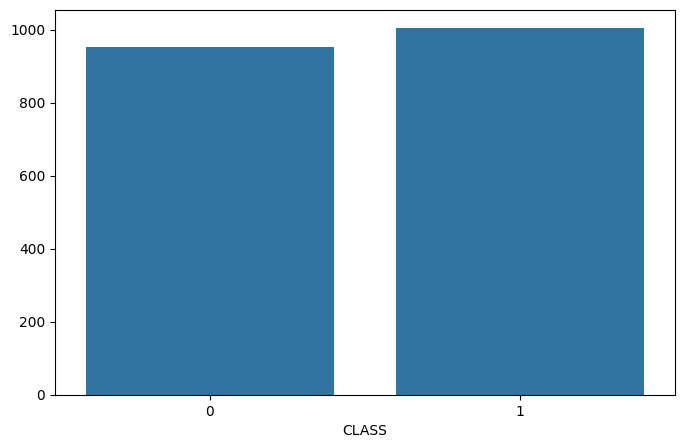

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
counts=df['CLASS'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=counts.index, y=counts.values)


In [47]:
df.duplicated().sum()

196

In [56]:
dups=df[df.duplicated(keep=False)]
dups.head(2)

,CONTENT,CLASS
84,PSY - GANGNAM STYLE (강남스타일) M/V: http://youtu....,0
110,Hi everyone! Do you like music? Then why not c...,1


In [57]:
df[df.eq(df.loc[84]).all(axis=1)]

,CONTENT,CLASS
84,PSY - GANGNAM STYLE (강남스타일) M/V: http://youtu....,0
125,PSY - GANGNAM STYLE (강남스타일) M/V: http://youtu....,0


In [59]:
df.drop_duplicates(inplace=True)

In [48]:
df.describe()

,CLASS
count,1955.000000
mean,0.513555
std,0.499944
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [60]:
df.shape

(1759, 2)

In [79]:
inputS=df['CONTENT']
Target=df['CLASS']

In [80]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test=train_test_split(inputS,Target,test_size=0.2,random_state=42)

In [81]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1407,), (352,), (1407,), (352,))

In [82]:
X_train[0]

'Huh, anyway check out this you[tube] channel: kobyoshi02'

In [70]:
y_train.value_counts()

CLASS
0    725
1    682
Name: count, dtype: int64

In [71]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer()

In [72]:
x_train=vectorizer.fit_transform(X_train)
x_test=vectorizer.transform(X_test)

In [73]:
x_train.shape

(1407, 3827)

In [78]:
x_train[0].toarray()

array([[0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [87]:
y_train.value_counts()

CLASS
0    725
1    682
Name: count, dtype: int64

In [84]:
from sklearn.naive_bayes import MultinomialNB
clf=MultinomialNB()

In [85]:
clf.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[725.,682.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.72]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3827)","[[ 1.,29., 1.,..., 1., 0., 0.], [ 4.,28., 0.,..., 0., 1., 1.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3827)","[[-8.54,-5.83,-8.54,...,-8.54,-9.23,-9.23], [-8.28,-6.52,-9.89,...,-9.89,-9.19,-9.19]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3827


In [89]:
clf.feature_count_[0,0]

1.0

In [90]:
y_pred=clf.predict(x_test)

<Axes: xlabel='col_0', ylabel='CLASS'>

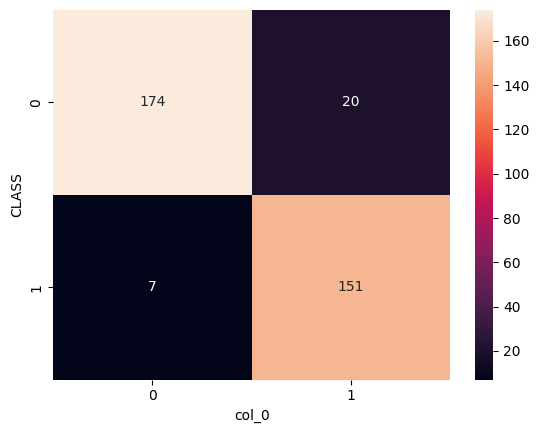

In [91]:
sns.heatmap(pd.crosstab(y_test,y_pred),annot=True,fmt='d')


In [93]:
Confusion_matrix=pd.crosstab(y_test,y_pred)
Confusion_matrix

col_0,0,1
CLASS,,
0,174,20
1,7,151


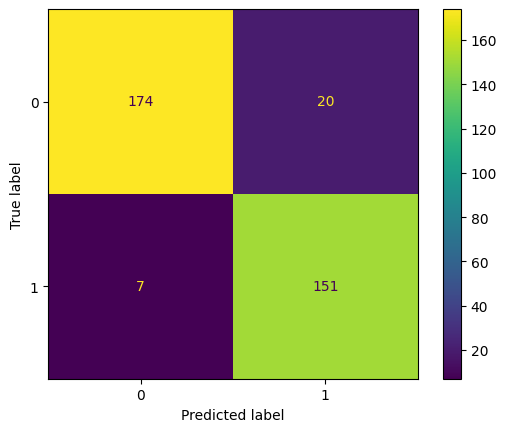

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)


In [129]:
from sklearn import metrics
print (metrics.classification_report(y_test,y_pred,target_names=["Ham","Spam"]))

              precision    recall  f1-score   support

         Ham       0.96      0.90      0.93       194
        Spam       0.88      0.96      0.92       158

    accuracy                           0.92       352
   macro avg       0.92      0.93      0.92       352
weighted avg       0.93      0.92      0.92       352



In [130]:
new_data=["I am not interested in this video","click on this link and win 100$"]
new_data_vectorized = vectorizer.transform(new_data)

In [131]:
new_data_vectorized.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [132]:
clf.predict(new_data_vectorized)

array([0, 1], dtype=int64)

In [154]:
import glob
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Load data
files = glob.glob("youtube-dataset/*.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df = df.drop(["COMMENT_ID", "AUTHOR", "DATE"], axis=1).drop_duplicates()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df["CONTENT"], df["CLASS"], test_size=0.2, random_state=42
)

# Vectorize and train
vectorizer = CountVectorizer()
x_train = vectorizer.fit_transform(X_train)

clf = MultinomialNB()
clf.fit(x_train, y_train)

# Generate synthetic samples from the learned class distribution
vocab = np.asarray(vectorizer.get_feature_names_out())
n_words_per_sample = 10
samples_per_class = 3

synthetic_samples = []

for cls in clf.classes_:
    cls_idx = np.where(clf.classes_ == cls)[0][0]
    probs = np.exp(clf.feature_log_prob_[cls_idx]).ravel()
    probs = probs / probs.sum()

    for _ in range(samples_per_class):
        sampled_idx = np.random.choice(
            len(vocab), size=n_words_per_sample, p=probs, replace=True
        )
        text = " ".join(vocab[sampled_idx])
        synthetic_samples.append((cls, text))
        print(f"{cls}: {text}")

synthetic_samples

0: english 19255 dead2me as there prove why billion this never
0: love airlines yesterday never sound the makeuptransformation shuffle ballad it
0: time press the code cevxzvsjlk8 cried your love cxpzpgb past
1: forward don young amp am reading check you for tried
1: quot could shoot making katy don will water start website
1: apologies it in 327568907427561 problems br thank and play dresses


[(0, 'english 19255 dead2me as there prove why billion this never'),
 (0,
  'love airlines yesterday never sound the makeuptransformation shuffle ballad it'),
 (0, 'time press the code cevxzvsjlk8 cried your love cxpzpgb past'),
 (1, 'forward don young amp am reading check you for tried'),
 (1, 'quot could shoot making katy don will water start website'),
 (1, 'apologies it in 327568907427561 problems br thank and play dresses')]